# Analiza nogometnih tekem

Podatki: **Premier League** (2010/11-2020/21), **La Liga** (2012/13-2020/21) in **Bundesliga** (2010/11-2020/21).

Vir: [footballcsv](https://github.com/footballcsv) - javno dostopni (public domain, CC0) rezultati tekem.

Skupaj **10.426 tekem**, pridobljenih in ociscenih s cevovodom `main.py -> zajem.py -> izluscenje.py -> naredi_csv.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from analiza_funkcije import (
    doloci_zmagovalca, je_veliko_golov, je_derbi, normaliziraj_ime_ekipe,
)

df = pd.read_csv("podatki/tekme.csv")
df["skupaj_goli"] = df["goli_domaci"] + df["goli_gosti"]
df["zmagovalec"] = df.apply(doloci_zmagovalca, axis=1)
df.head()

,datum,domaca_ekipa,gostujoca_ekipa,goli_domaci,goli_gosti,liga,sezona,skupaj_goli,zmagovalec
0,Fri Aug 20 2010,Bayern München,VfL Wolfsburg,2,1,Bundesliga,2010-11,3,Domacini
1,Sat Aug 21 2010,1. FC Köln,1. FC Kaiserslautern,1,3,Bundesliga,2010-11,4,Gostje
2,Sat Aug 21 2010,SC Freiburg,FC St. Pauli,1,3,Bundesliga,2010-11,4,Gostje
3,Sat Aug 21 2010,Bor. Mönchengladbach,1. FC Nürnberg,1,1,Bundesliga,2010-11,2,Neodloceno
4,Sat Aug 21 2010,TSG 1899 Hoffenheim,Werder Bremen,4,1,Bundesliga,2010-11,5,Domacini


## 1. Osnovni pregled podatkov

In [2]:
print(f"Skupaj tekem: {len(df)}")
print(f"Lige: {sorted(df['liga'].unique())}")
pregled = df.groupby("liga").agg(
    stevilo_tekem=("skupaj_goli", "size"),
    stevilo_sezon=("sezona", "nunique"),
    povprecje_golov=("skupaj_goli", "mean"),
).round(3)
pregled

Skupaj tekem: 10426
Lige: ['Bundesliga', 'La Liga', 'Premier League']


,stevilo_tekem,stevilo_sezon,povprecje_golov
liga,,,
Bundesliga,3123,11,2.956
La Liga,3123,9,2.707
Premier League,4180,11,2.741


## 2. Cisenje podatkov - poenotenje imen ekip

Isto ekipo najdemo zapisano na vec nacinov (npr. `Everton` in `Everton FC`, `Manchester Utd` in `Manchester United FC`). Ce tega ne bi popravili, bi analiza po ekipah delila isto ekipo na vec "razlicnih" ekip. Funkcija `normaliziraj_ime_ekipe` v `analiza_funkcije.py` to popravi.

In [3]:
# Primerjava stevila unikatnih imen ekip pred in po poenotenju (Premier League)
pl = df[df["liga"] == "Premier League"].copy()
imena_pred = set(pl["domaca_ekipa"]) | set(pl["gostujoca_ekipa"])

df["domaca_ekipa_n"] = df["domaca_ekipa"].apply(normaliziraj_ime_ekipe)
df["gostujoca_ekipa_n"] = df["gostujoca_ekipa"].apply(normaliziraj_ime_ekipe)

pl_n = df[df["liga"] == "Premier League"]
imena_po = set(pl_n["domaca_ekipa_n"]) | set(pl_n["gostujoca_ekipa_n"])

print(f"Unikatnih imen pred poenotenjem: {len(imena_pred)}")
print(f"Unikatnih imen po poenotenju:    {len(imena_po)}")

Unikatnih imen pred poenotenjem: 56
Unikatnih imen po poenotenju:    38


## 3. Povprecno stevilo golov na tekmo po ligi

liga
Bundesliga        2.956
Premier League    2.741
La Liga           2.707
Name: skupaj_goli, dtype: float64


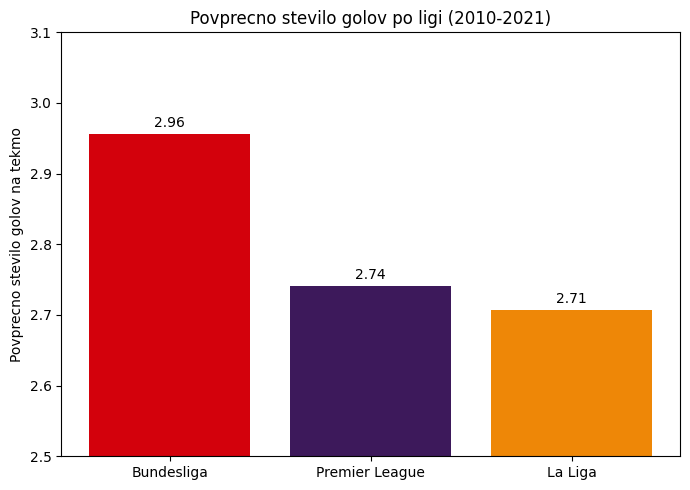

In [4]:
povprecje_po_ligi = df.groupby("liga")["skupaj_goli"].mean().sort_values(ascending=False)
print(povprecje_po_ligi.round(3))

plt.figure(figsize=(7, 5))
barve = {"Bundesliga": "#d3010c", "Premier League": "#3d195b", "La Liga": "#ee8707"}
plt.bar(povprecje_po_ligi.index, povprecje_po_ligi.values,
        color=[barve[l] for l in povprecje_po_ligi.index])
plt.ylabel("Povprecno stevilo golov na tekmo")
plt.title("Povprecno stevilo golov po ligi (2010-2021)")
plt.ylim(2.5, 3.1)
for i, v in enumerate(povprecje_po_ligi.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

**Ugotovitev:** Bundesliga v povprecju prinese najvec golov na tekmo, kar se sklada z znanim slovesom nemske lige po napadalnem, odprtem nogometu.

## 4. Trend golov skozi sezone - primerjava treh lig

liga     Bundesliga  La Liga  Premier League
sezona                                      
2010-11       2.922      NaN           2.797
2011-12       2.859      NaN           2.805
2012-13       2.935    2.871           2.797
2013-14       3.160    2.750           2.768
2014-15       2.755    2.655           2.566
2015-16       2.830    2.745           2.700
2016-17       2.866    2.942           2.800
2017-18       2.794    2.695           2.679
2018-19       3.180    2.587           2.821
2019-20       3.209    2.479           2.721
2020-21       3.206    2.410           2.695


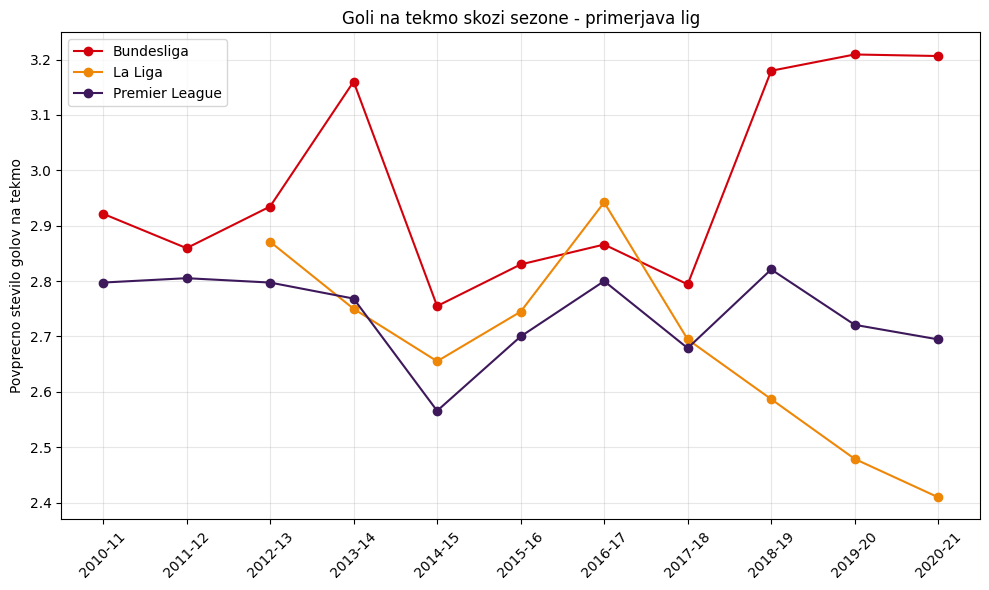

In [5]:
trend = df.groupby(["sezona", "liga"])["skupaj_goli"].mean().unstack()
print(trend.round(3))

plt.figure(figsize=(10, 6))
for liga in trend.columns:
    plt.plot(trend.index, trend[liga], marker="o", label=liga, color=barve[liga])
plt.xticks(rotation=45)
plt.ylabel("Povprecno stevilo golov na tekmo")
plt.title("Goli na tekmo skozi sezone - primerjava lig")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Ugotovitev:** Vse tri lige nihajo znotraj podobnega razpona (~2,5-3,1 gola/tekmo), brez jasnega dolgorocnega trenda navzgor ali navzdol v tem obdobju. La Liga ima najbolj "stabilno" povprecje, Bundesliga najvecje nihanje med sezonami.

## 5. Porazdelitev stevila golov na tekmo

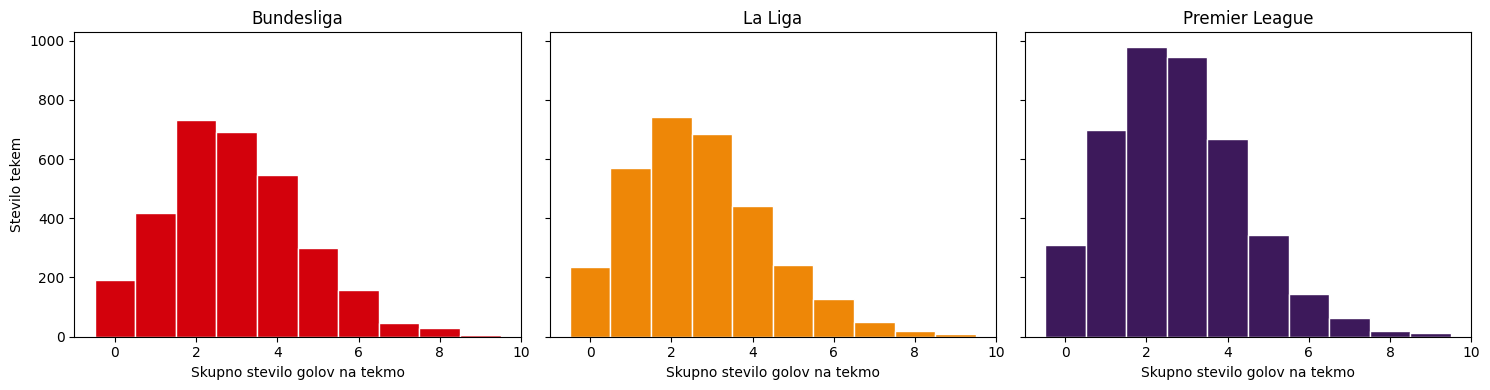

In [6]:
fig, osi = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for os, liga in zip(osi, sorted(df["liga"].unique())):
    podatki_lige = df[df["liga"] == liga]["skupaj_goli"]
    os.hist(podatki_lige, bins=range(0, 11), color=barve[liga], edgecolor="white", align="left")
    os.set_title(liga)
    os.set_xlabel("Skupno stevilo golov na tekmo")
osi[0].set_ylabel("Stevilo tekem")
plt.tight_layout()
plt.show()

## 6. Domaca prednost (delez zmag domacih / gostov / neodloceno)

zmagovalec      Domacini  Neodloceno  Gostje
liga                                        
Bundesliga          45.1        24.2    30.7
La Liga             46.7        24.5    28.8
Premier League      45.0        24.4    30.6


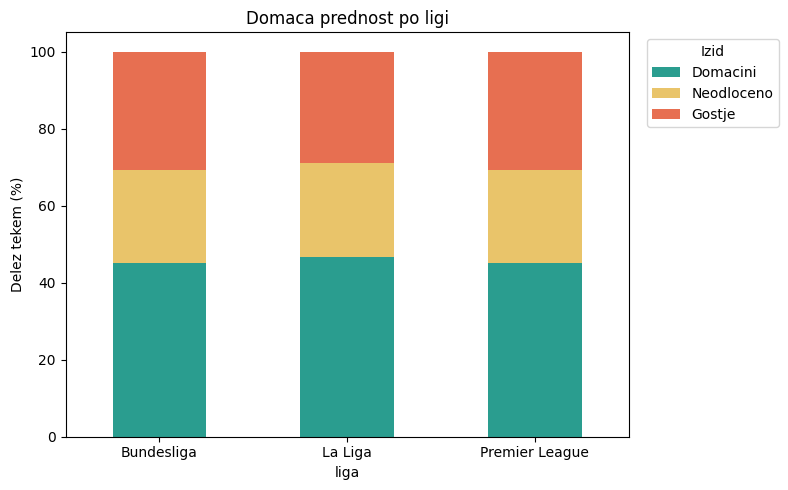

In [7]:
delez_zmag = (
    df.groupby(["liga", "zmagovalec"]).size().unstack()
    .apply(lambda x: 100 * x / x.sum(), axis=1)
    [["Domacini", "Neodloceno", "Gostje"]]
)
print(delez_zmag.round(1))

delez_zmag.plot(kind="bar", stacked=True, figsize=(8, 5),
                color=["#2a9d8f", "#e9c46a", "#e76f51"])
plt.ylabel("Delez tekem (%)")
plt.title("Domaca prednost po ligi")
plt.xticks(rotation=0)
plt.legend(title="Izid", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Domaca prednost skozi cas

liga     Bundesliga  La Liga  Premier League
sezona                                      
2010-11        46.1      NaN            47.1
2011-12        45.4      NaN            45.0
2012-13        42.5     49.7            43.7
2013-14        47.4     47.1            47.1
2014-15        47.4     45.0            45.3
2015-16        44.1     48.2            41.3
2016-17        49.0     47.6            49.2
2017-18        45.4     47.1            45.5
2018-19        45.1     44.2            47.6
2019-20        40.2     45.8            45.3
2020-21        36.5     41.0            37.9


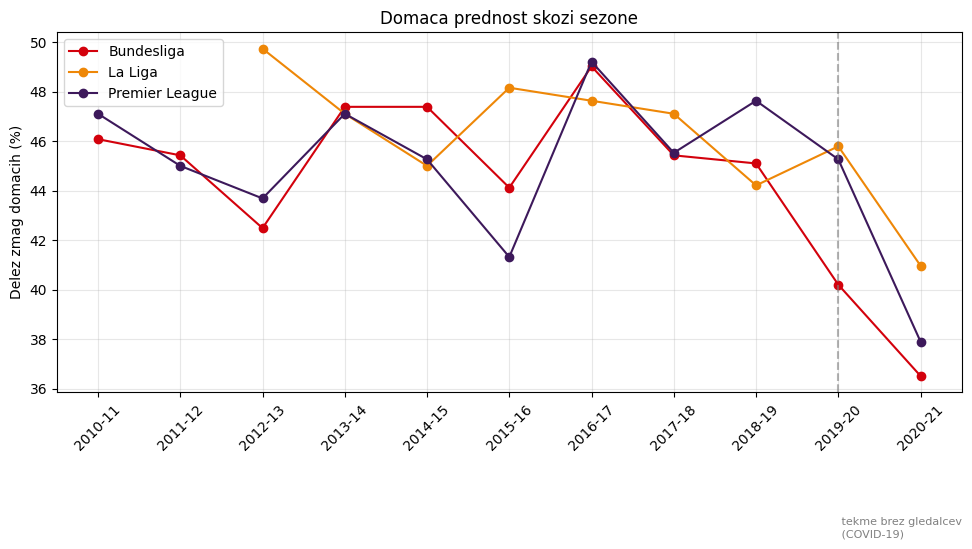

In [8]:
domaca_prednost_skozi_cas = (
    df[df["zmagovalec"] == "Domacini"]
    .groupby(["sezona", "liga"]).size()
    .div(df.groupby(["sezona", "liga"]).size())
    .mul(100)
    .unstack()
)
print(domaca_prednost_skozi_cas.round(1))

plt.figure(figsize=(10, 6))
for liga in domaca_prednost_skozi_cas.columns:
    plt.plot(domaca_prednost_skozi_cas.index, domaca_prednost_skozi_cas[liga],
             marker="o", label=liga, color=barve[liga])
plt.axvline("2019-20", color="gray", linestyle="--", alpha=0.6)
plt.text("2019-20", 30, " tekme brez gledalcev\n (COVID-19)", fontsize=8, color="gray")
plt.xticks(rotation=45)
plt.ylabel("Delez zmag domacih (%)")
plt.title("Domaca prednost skozi sezone")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Ugotovitev:** V sezoni 2019/20 in 2020/21 (ko so tekme zaradi COVID-19 potekale brez gledalcev) domaca prednost opazno pade v vseh treh ligah - to je lep primer, kako podatki potrdijo znano hipotezo, da del domace prednosti prihaja od podpore navijacev na tribunah.

## 8. Najboljse napadalne ekipe (povprecno doseženih golov na tekmo)

In [9]:
def najboljsi_napadalci(liga, top_n=10):
    pod = df[df["liga"] == liga]
    doma = pod.groupby("domaca_ekipa_n")["goli_domaci"].agg(["sum", "count"])
    gost = pod.groupby("gostujoca_ekipa_n")["goli_gosti"].agg(["sum", "count"])
    skupaj = doma.add(gost, fill_value=0)
    skupaj["povprecje"] = skupaj["sum"] / skupaj["count"]
    # samo ekipe z vsaj eno celo sezono tekem, da izlocimo ekipe z le nekaj tekmami
    skupaj = skupaj[skupaj["count"] >= 30]
    return skupaj.sort_values("povprecje", ascending=False).head(top_n)

top_pl = najboljsi_napadalci("Premier League")
top_pl[["count", "povprecje"]].round(2)

,count,povprecje
domaca_ekipa_n,,
Manchester City,418,2.25
Liverpool,418,1.91
Arsenal,418,1.81
Manchester United,418,1.80
Chelsea,418,1.79
Tottenham Hotspur,418,1.73
Leeds United,38,1.63
Leicester City,266,1.52
Blackpool,38,1.45


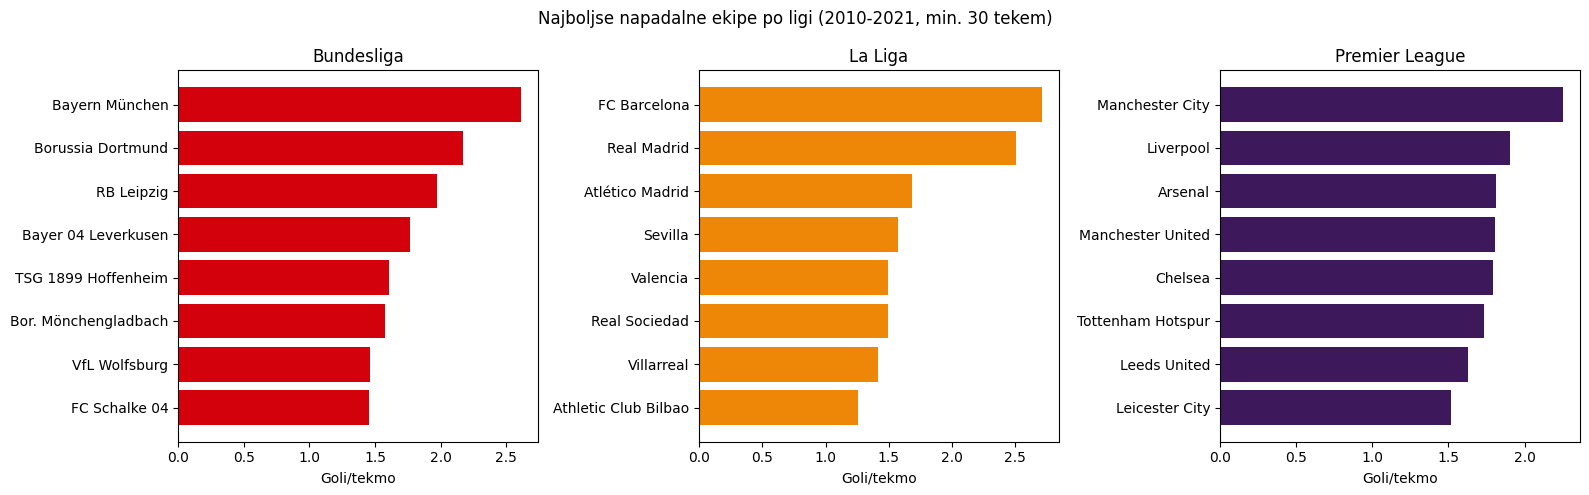

In [10]:
fig, osi = plt.subplots(1, 3, figsize=(16, 5))
for os, liga in zip(osi, sorted(df["liga"].unique())):
    top = najboljsi_napadalci(liga, top_n=8)
    os.barh(top.index[::-1], top["povprecje"][::-1], color=barve[liga])
    os.set_title(liga)
    os.set_xlabel("Goli/tekmo")
plt.suptitle("Najboljse napadalne ekipe po ligi (2010-2021, min. 30 tekem)")
plt.tight_layout()
plt.show()

**Ugotovitev:** Vodilne ekipe (Bayern München, Real Madrid/Barcelona, Manchester City) dosegajo bistveno vec kot dvakratnik lige-povprecja golov na tekmo, kar potrjuje veliko razliko v moci med vrhom in sredino/dnom lestvice.

## 9. Tekme z veliko goli in derbiji

In [11]:
df["veliko_golov"] = df.apply(je_veliko_golov, axis=1)
df["derbi"] = df.apply(je_derbi, axis=1)

delez_veliko_golov = df.groupby("liga")["veliko_golov"].mean() * 100
print("Delez tekem z vec kot 4 goli po ligi:")
print(delez_veliko_golov.round(1))
print()
print(f"Skupno stevilo prepoznanih derbi tekem: {df['derbi'].sum()}")
df[df["derbi"]][["datum", "domaca_ekipa", "gostujoca_ekipa", "goli_domaci", "goli_gosti", "sezona"]].head(10)

Delez tekem z vec kot 4 goli po ligi:
liga
Bundesliga        17.4
La Liga           14.4
Premier League    13.9
Name: veliko_golov, dtype: float64

Skupno stevilo prepoznanih derbi tekem: 61


,datum,domaca_ekipa,gostujoca_ekipa,goli_domaci,goli_gosti,sezona
3200,Sun Oct 17 2010,Everton FC,Liverpool FC,2,0,2010-11
3239,Wed Nov 10 2010,Manchester City FC,Manchester United FC,0,0,2010-11
3343,Sun Jan 16 2011,Liverpool FC,Everton FC,2,2,2010-11
3378,Sat Feb 12 2011,Manchester United FC,Manchester City FC,2,1,2010-11
3567,Sat Oct 1 2011,Everton FC,Liverpool FC,0,2,2011-12
3590,Sun Oct 23 2011,Manchester United FC,Manchester City FC,1,6,2011-12
3782,Tue Mar 13 2012,Liverpool FC,Everton FC,3,0,2011-12
3858,Mon Apr 30 2012,Manchester City FC,Manchester United FC,1,0,2011-12
3970,Sun Oct 28 2012,Everton FC,Liverpool FC,2,2,2012-13
4038,Sun Dec 9 2012,Manchester City FC,Manchester United FC,2,3,2012-13


## 10. Ekstremi - najvec golov na eni tekmi

In [12]:
najvec_golov = df.sort_values("skupaj_goli", ascending=False).head(10)
najvec_golov[["datum", "domaca_ekipa", "goli_domaci", "goli_gosti", "gostujoca_ekipa", "liga", "sezona"]]

,datum,domaca_ekipa,goli_domaci,goli_gosti,gostujoca_ekipa,liga,sezona
8597,Sun Dec 20 2015,Real Madrid,10,2,Rayo Vallecano,La Liga,2015-16
850,Sat Mar 30 2013,Bayern München,9,2,Hamburger SV,Bundesliga,2012-13
7787,Wed Oct 30 2013,Real Madrid,7,3,Sevilla FC,La Liga,2013-14
4256,Sun May 19 2013,West Bromwich Albion FC,5,5,Manchester United FC,Premier League,2012-13
8094,Sat Sep 20 2014,RCD La Coruña,2,8,Real Madrid,La Liga,2014-15
9610,Sun Sep 2 2018,FC Barcelona,8,2,SD Huesca,La Liga,2018-19
4075,Sat Dec 29 2012,Arsenal FC,7,3,Newcastle United FC,Premier League,2012-13
8827,Sat Aug 20 2016,Sevilla FC,6,4,RCD Espanyol,La Liga,2016-17
3528,Sun Aug 28 2011,Manchester United FC,8,2,Arsenal FC,Premier League,2011-12
8348,Sun Apr 5 2015,Real Madrid,9,1,Granada CF,La Liga,2014-15


## 11. Zakljucne ugotovitve

- **Bundesliga** ima v povprecju najvec golov na tekmo (~2,96), sledita **Premier League** (~2,74) in **La Liga** (~2,71).
- **Domaca prednost** je v vseh treh ligah podobna (~45 % zmag domacih), a v sezonah brez gledalcev (2019/20-2020/21, COVID-19) opazno upade - kar podpira hipotezo, da navijaci prispevajo k domaci prednosti.
- Vec kot 4 gole je padlo na **1.573 od 10.426 tekem (~15 %)**.
- Imena ekip **niso zapisana konsistentno** skozi sezone (npr. "Everton" vs. "Everton FC") - to je bilo treba popraviti pred analizo po ekipah, sicer bi se ista ekipa razdelila na vec "razlicnih" vnosov.
- Najbolj napadalno naravnane ekipe (Bayern München, Real Madrid, Barcelona, Manchester City) dosegajo bistveno vec golov od povprecja lige, kar kaze na veliko razliko v moci med vrhom in ostalimi ekipami.